<a href="https://colab.research.google.com/github/u8101081741-source/MISSP/blob/MIS/lab_auto_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pulp sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.5/151.5 kB 6.4 MB/s eta 0:00:00


# Statistics & Machine Learning in Automation and Operations

Machne learning is a field of AI that focuses on building systems that learn from data.
The goal is to use data to understand the underlying patterns and make predictions.

In general we can use:

- in a supervised way, where we somehow "know" an answer to a particular question (on trainining questions), for example: we know which engines broke based on their behaviour or we know which images show us defects
- in an unsupervised way, where we have data but we don't nesseesarely know the answers. What we ask the AI to do is to somehow divide the data into meaningfull parterns or try to compress it i.e. find features that describe best our data. For example the model can show how a "healthy machine" behaves on a factory floor and will enable us to distinguish it from a faulty ones
- reinforcement learning is a learning where we give "points/ awards" for a good results not nessesarely focusing on particular behaviours or singular decisions. For example we may train a robot to walk by awarding how far he could get without falling.

# Time series forecasting

Time series forecasting is a type of supervised learning where we use historical data to predict future values.





(<Figure size 1600x400 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x7fec64ea5208>)

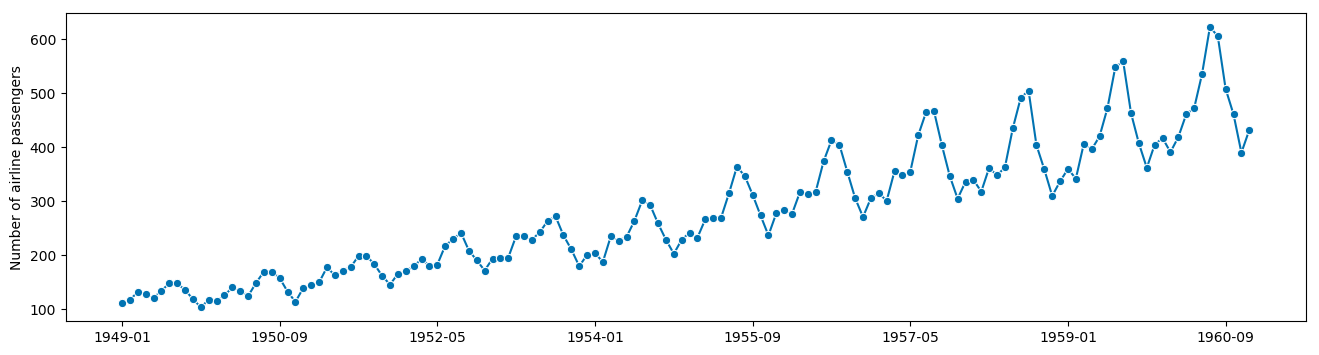

In [ ]:
from sktime.datasets import load_airline
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.naive import NaiveForecaster
import numpy as np
y = load_airline() #we load an example dataset showing the monthly number of passengers on an airline

# plotting for visualization
plot_series(y)

/home/igor/anaconda3/lib/python3.7/site-packages/sktime/utils/seasonality.py:126: FutureWarning: casting period[M] values to int64 with .astype(...) is deprecated and will raise in a future version. Use .view(...) instead.
  aix_int = aix.astype("int64")
/home/igor/anaconda3/lib/python3.7/site-packages/sktime/utils/seasonality.py:140: FutureWarning: casting period[M] values to int64 with .astype(...) is deprecated and will raise in a future version. Use .view(...) instead.
  ix = ix.astype("int64")


(<Figure size 1600x400 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x7fec65016198>)

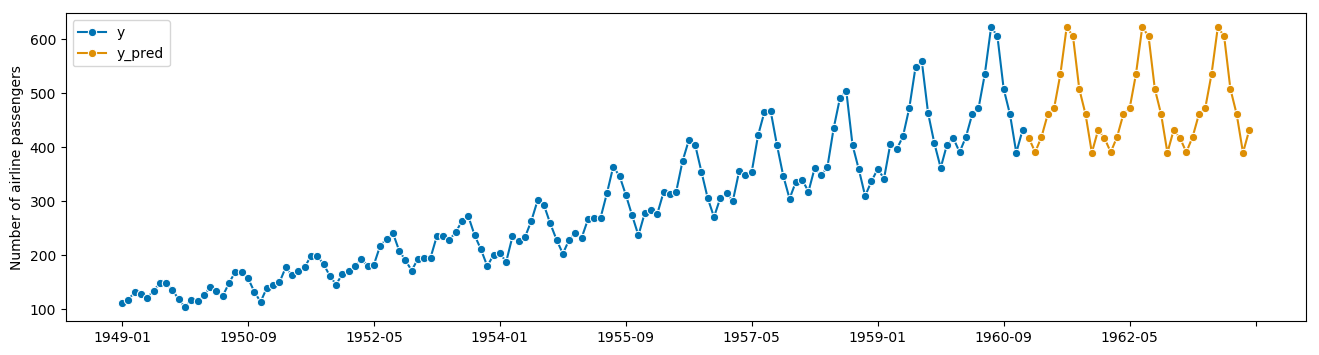

In [ ]:
# step 2: specifying forecasting horizon
fh = np.arange(1, 37)

# step 3: specifying the forecasting algorithm
forecaster = NaiveForecaster(strategy="last", sp=12)



# step 4: fitting the forecaster
forecaster.fit(y)

# step 5: querying predictions
y_pred = forecaster.predict(fh)
# optional: plotting predictions and past data
plot_series(y, y_pred, labels=["y", "y_pred"])


[notice] A new release of pip is available: 23.0.1 -> 24.0
[notice] To update, run: pip install --upgrade pip


22:31:15 - cmdstanpy - INFO - Chain [1] start processing
22:31:15 - cmdstanpy - INFO - Chain [1] done processing


(<Figure size 1600x400 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x7fec64fe0320>)

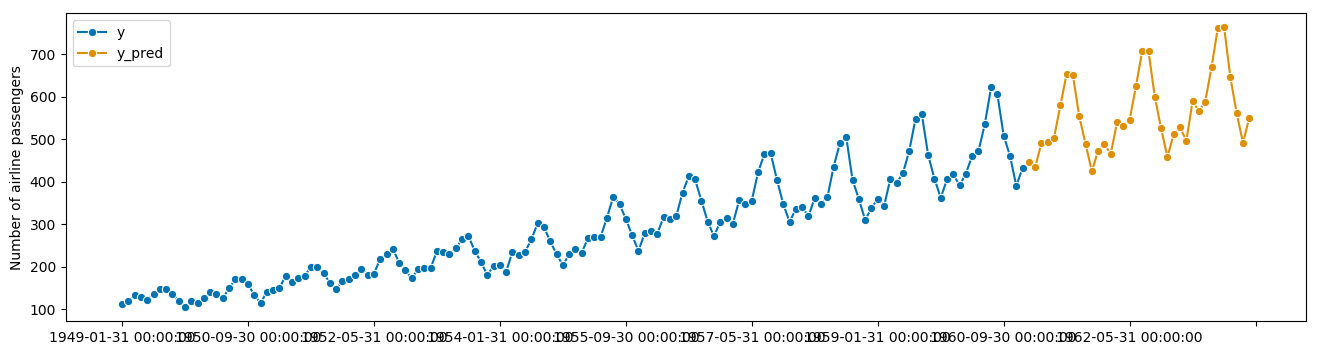

In [ ]:
!pip install prophet
from sktime.datasets import load_airline
from sktime.forecasting.fbprophet import Prophet
# Prophet requires to have data with a pandas.DatetimeIndex
ym = load_airline().to_timestamp(freq='M')
forecaster = Prophet(
    seasonality_mode='multiplicative',
    n_changepoints=int(len(y) / 12),
    add_country_holidays={'country_name': 'Germany'},
    yearly_seasonality=True)
forecaster.fit(ym)
Prophet(...)
y_predm = forecaster.predict(fh)
plot_series(ym, y_predm, labels=["y", "y_pred"])

# Excercise:
 download the prices of : eggs, chicken, beef, milk from https://fred.stlouisfed.org/categories/32217, other if you want

estimate what is the best blend of products for the cat food problem for june of this year, is it the same for september?


Steps:
- load the data
- plot the data
- try to find a model that forecasts the data well
- make a prediction for june of this year
- make a prediction for september of this year
- use the predictions to put the price of the blend of products on the market
- use a typical linear programming model to find the best blend of products that minimizes the cost of the blend

In [20]:
import pandas_datareader.data as pdr
import pandas as pd
import datetime

# Define the FRED series IDs for each product
fred_series = {
    'Eggs': 'APU0000708111',
    'Chicken': 'APU0000706111',
    'Beef': 'APU0000703112',
    'Milk': 'APU0000709112'
}

# Initialize an empty list to store individual product DataFrames
product_series_list = []

# Define a start date for historical data
start_date = datetime.datetime(2000, 1, 1)

print("Downloading historical data from FRED...")

# Loop through the dictionary of product names and FRED series IDs
for product_name, series_id in fred_series.items():
    try:
        # Attempt to download the data for each series
        data = pdr.DataReader(series_id, 'fred', start_date)
        # Rename the column to the product name for clarity
        data = data.rename(columns={series_id: product_name})
        product_series_list.append(data)
        print(f"Successfully downloaded data for {product_name}.")
    except Exception as e:
        print(f"Error downloading data for {product_name} (Series ID: {series_id}): {e}")
        # Append an empty DataFrame or handle as appropriate
        # For now, we'll just skip this product if an error occurs
        pass

# Concatenate all the Series in the list into a single pandas DataFrame
if product_series_list:
    df_prices = pd.concat(product_series_list, axis=1)
    print("Historical price data successfully loaded into df_prices.")
    print(df_prices.head())
else:
    df_prices = pd.DataFrame()
    print("No data was successfully downloaded to create df_prices.")


Successfully downloaded data for Eggs.
Successfully downloaded data for Chicken.
Successfully downloaded data for Beef.
Successfully downloaded data for Milk.
Historical price data successfully loaded into df_prices.
             Eggs  Chicken   Beef   Milk
DATE                                    
2000-01-01  0.975    1.059  1.483  2.785
2000-02-01  0.962    1.046  1.516  2.777
2000-03-01  0.931    1.064  1.532  2.748
2000-04-01  0.939    1.069  1.584  2.773
2000-05-01  0.852    1.052  1.570  2.782


Missing values after ffill and bfill:
Eggs       0
Chicken    0
Beef       0
Milk       0
dtype: int64
Generating plots for each product...
Plot for Eggs generated.
Plot for Chicken generated.
Plot for Beef generated.
Plot for Milk generated.


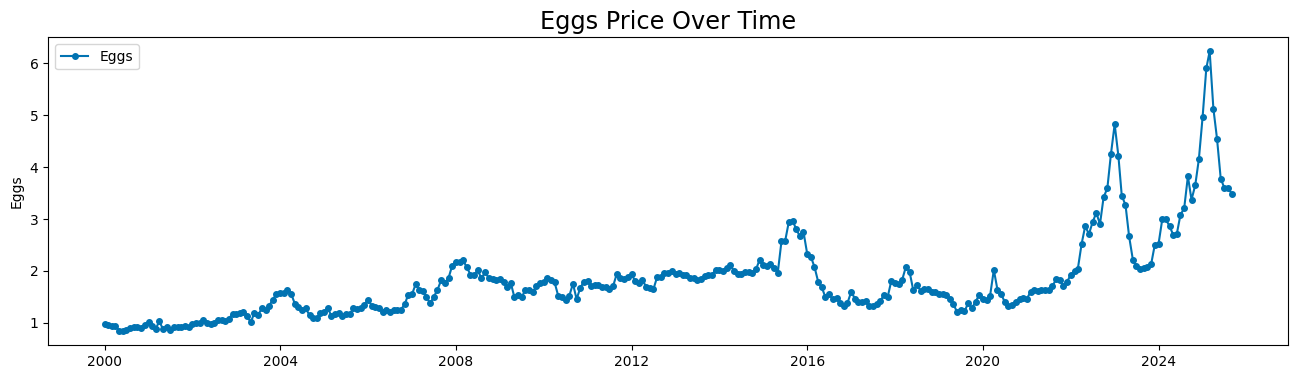

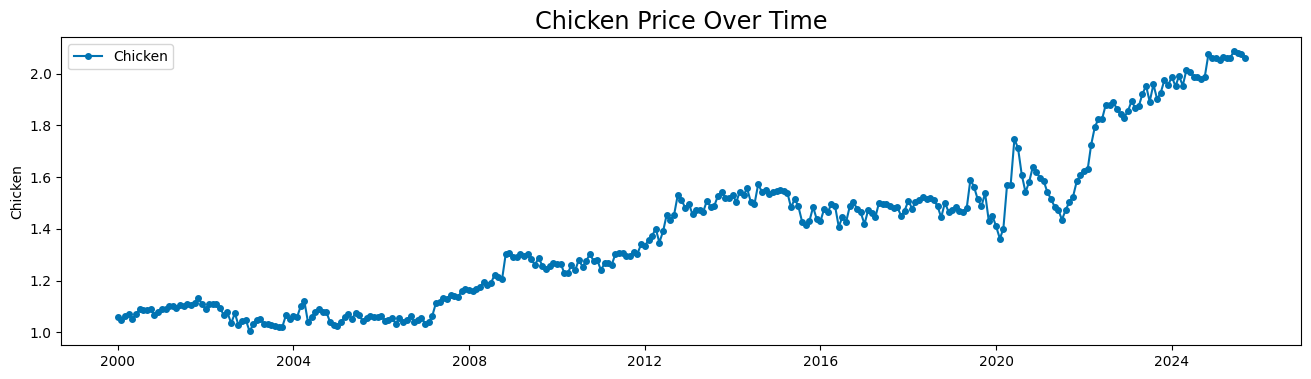

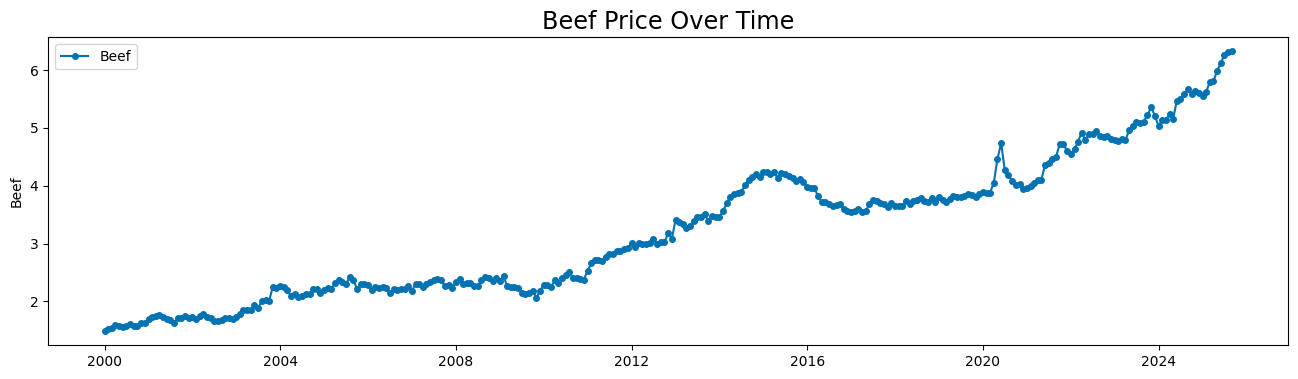

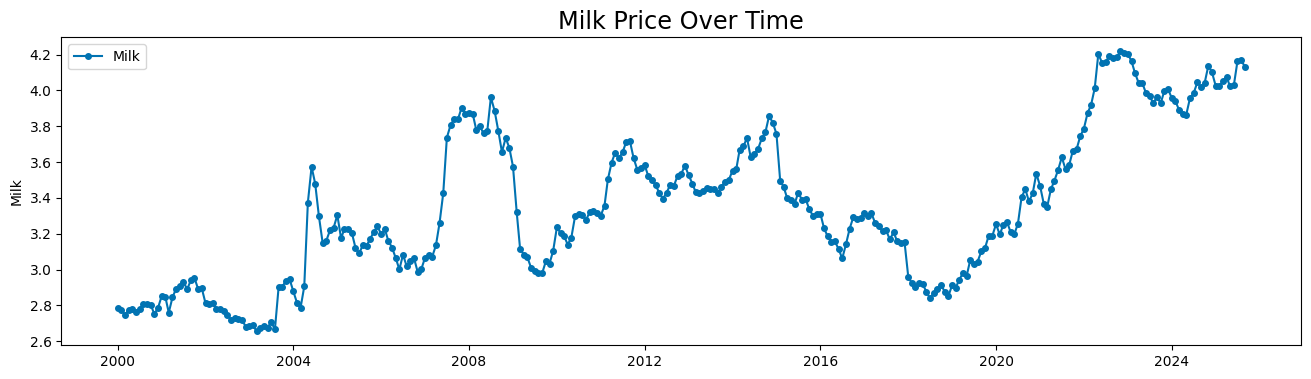

In [21]:
from sktime.utils.plotting import plot_series

# 1. Handle missing values: forward-fill then back-fill
df_prices = df_prices.ffill().bfill()
print("Missing values after ffill and bfill:")
print(df_prices.isnull().sum())

# 3. and 4. Iterate and plot each product's price series
print("Generating plots for each product...")
for product_name in df_prices.columns:
    # Convert the column to a pandas Series with DatetimeIndex for sktime compatibility
    series = df_prices[product_name].dropna() # Drop any remaining NaNs if present at edges after bfill/ffill for robust plotting
    if not series.empty:
        plot_series(series, labels=[product_name], title=f'{product_name} Price Over Time')
        print(f"Plot for {product_name} generated.")
    else:
        print(f"No data to plot for {product_name}.")

In [22]:
from sktime.forecasting.fbprophet import Prophet
from sktime.forecasting.base import ForecastingHorizon
import datetime
import pandas as pd

# 1. Initialize an empty dictionary to store forecasted prices
forecasted_prices = {}

# 2. Get the current year (for target forecast dates)
current_year_for_forecast = datetime.datetime.now().year

print(f"Forecasting prices for June and September of {current_year_for_forecast}...")

# 3. Loop through each product column in df_prices
for product_name in df_prices.columns:
    print(f"Processing {product_name}...")
    # Convert the column to a pandas Series with DatetimeIndex
    y_product = df_prices[product_name].dropna()

    # Define the training data to end at the end of the year *prior* to the current forecast year
    # This ensures that the forecast dates are always in the future relative to the training data
    training_data_end_date = pd.Timestamp(year=current_year_for_forecast - 1, month=12, day=31)
    y_train_product = y_product[y_product.index <= training_data_end_date]

    # Check if there is enough training data after truncation
    if y_train_product.empty:
        print(f"Not enough training data for {product_name} to forecast {current_year_for_forecast}. Skipping.")
        continue

    # Instantiate a Prophet model
    n_changepoints_val = int(len(y_train_product) / 12) if len(y_train_product) > 12 else 1
    forecaster = Prophet(
        seasonality_mode='multiplicative',
        n_changepoints=n_changepoints_val,
        yearly_seasonality=True
    )

    # Fit the Prophet model to the truncated training data
    forecaster.fit(y_train_product)

    # Define the forecasting horizon for June and September of the current forecast year
    june_date = pd.Timestamp(year=current_year_for_forecast, month=6, day=1)
    september_date = pd.Timestamp(year=current_year_for_forecast, month=9, day=1)

    # Create a list of future forecast dates
    forecast_dates_list = [june_date, september_date]

    # Convert the list of Timestamps to a DatetimeIndex as required by ForecastingHorizon
    fh_dates = pd.DatetimeIndex(forecast_dates_list)

    # Create ForecastingHorizon from the DatetimeIndex
    fh = ForecastingHorizon(fh_dates, is_relative=False)

    # Use the fitted model to predict prices for the defined forecasting horizon
    y_pred = forecaster.predict(fh)

    # Store the predicted prices for June and September
    product_forecasts = {}
    if june_date in y_pred.index:
        product_forecasts['June'] = y_pred.loc[june_date]
    if september_date in y_pred.index:
        product_forecasts['September'] = y_pred.loc[september_date]

    if product_forecasts:
        forecasted_prices[product_name] = product_forecasts
        print(f"Forecast for {product_name}: {product_forecasts}")
    else:
        print(f"No predictions generated for {product_name}.")

print("\nAll forecasting complete.")
print("Final forecasted prices:")
print(forecasted_prices)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Forecasting prices for June and September of 2025...
Processing Eggs...
Forecast for Eggs: {'June': np.float64(3.028458605046598), 'September': np.float64(3.3601750039720413)}
Processing Chicken...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Forecast for Chicken: {'June': np.float64(2.112471092067902), 'September': np.float64(2.110798977419828)}
Processing Beef...
Forecast for Beef: {'June': np.float64(5.7889613748663775), 'September': np.float64(5.808658484082695)}
Processing Milk...
Forecast for Milk: {'June': np.float64(4.308791910009416), 'September': np.float64(4.379812881076264)}

All forecasting complete.
Final forecasted prices:
{'Eggs': {'June': np.float64(3.028458605046598), 'September': np.float64(3.3601750039720413)}, 'Chicken': {'June': np.float64(2.112471092067902), 'September': np.float64(2.110798977419828)}, 'Beef': {'June': np.float64(5.7889613748663775), 'September': np.float64(5.808658484082695)}, 'Milk': {'June': np.float64(4.308791910009416), 'September': np.float64(4.379812881076264)}}


In [24]:
from pulp import *

max_ingredient_percentage = 0.7

# Define products, their nutritional content per 100g (example values),
# and their forecasted prices for September
products_data_september = {
    'Eggs': {'protein': 13, 'fat': 11, 'calories': 155, 'price': forecasted_prices['Eggs']['September'] if 'Eggs' in forecasted_prices else 0},
    'Beef': {'protein': 26, 'fat': 15, 'calories': 250, 'price': forecasted_prices['Beef']['September'] if 'Beef' in forecasted_prices else 0},
    'Milk': {'protein': 3.4, 'fat': 3.6, 'calories': 61, 'price': forecasted_prices['Milk']['September'] if 'Milk' in forecasted_prices else 0}
}

# Filter out products with 0 price (i.e., not forecasted)
products_data_september_filtered = {k: v for k, v in products_data_september.items() if v['price'] > 0}

# Nutritional requirements for a 100g serving of cat food (example values)
# These remain the same as for June
min_protein = 25  # g
min_fat = 15      # g
min_calories = 100 # kcal
max_total_weight = 100 # g (for a 100g serving)

# Create the LP problem object for September
prob_september = LpProblem("Cat_Food_Blend_September", LpMinimize)

# Decision variables: quantity (in grams) of each product in the blend for September
x_september = LpVariable.dicts("quantity", products_data_september_filtered.keys(), 0, None, LpContinuous)

# Objective function: minimize the total cost for September
prob_september += lpSum([products_data_september_filtered[i]['price'] * x_september[i] for i in products_data_september_filtered]), "Total Cost September"

# Constraints for September (same as June)
# 1. Total weight constraint (100g serving)
prob_september += lpSum([x_september[i] for i in products_data_september_filtered]) == max_total_weight, "Total Weight September"

# 2. Minimum protein constraint
prob_september += lpSum([products_data_september_filtered[i]['protein'] * x_september[i] / 100 for i in products_data_september_filtered]) >= min_protein, "Minimum Protein September"

# 3. Minimum fat constraint
prob_september += lpSum([products_data_september_filtered[i]['fat'] * x_september[i] / 100 for i in products_data_september_filtered]) >= min_fat, "Minimum Fat September"

# 4. Minimum calories constraint
prob_september += lpSum([products_data_september_filtered[i]['calories'] * x_september[i] / 100 for i in products_data_september_filtered]) >= min_calories, "Minimum Calories September"

# 5. Maximum percentage per ingredient constraint
for i in products_data_september_filtered:
    prob_september += x_september[i] <= max_ingredient_percentage * max_total_weight, f"Max {i} Percentage September"

# Solve the problem for September
prob_september.solve()

# Print the results for September
print("--- September Optimal Blend ---")
print("Status:", LpStatus[prob_september.status])
print("Total Cost per 100g serving:", value(prob_september.objective))

september_blend_composition = {}
for v in prob_september.variables():
    if v.varValue > 0.0001: # Only show non-zero quantities
        print(f"{v.name}: {v.varValue:.2f} grams")
        september_blend_composition[v.name.replace('quantity_', '')] = v.varValue

# Store the results for later comparison
optimal_blend_september = {
    'cost': value(prob_september.objective),
    'composition': september_blend_composition
}

--- September Optimal Blend ---
Status: Infeasible
Total Cost per 100g serving: 582.369093059657
quantity_Beef: 70.00 grams
quantity_Eggs: 52.31 grams


In [28]:
from pulp import *

max_ingredient_percentage = 0.7

# Define products, their nutritional content per 100g (example values),
# and their forecasted prices for June
products_data_june = {
    'Eggs': {'protein': 13, 'fat': 11, 'calories': 155, 'price': forecasted_prices['Eggs']['June'] if 'Eggs' in forecasted_prices else 0},
    'Beef': {'protein': 26, 'fat': 15, 'calories': 250, 'price': forecasted_prices['Beef']['June'] if 'Beef' in forecasted_prices else 0},
    'Milk': {'protein': 3.4, 'fat': 3.6, 'calories': 61, 'price': forecasted_prices['Milk']['June'] if 'Milk' in forecasted_prices else 0}
}

# Filter out products with 0 price (i.e., not forecasted)
products_data_june_filtered = {k: v for k, v in products_data_june.items() if v['price'] > 0}

# Nutritional requirements for a 100g serving (same as September)
min_protein = 25   # g
min_fat = 15       # g
min_calories = 100 # kcal
max_total_weight = 100 # g per serving

# Create LP problem for June
prob_june = LpProblem("Cat_Food_Blend_June", LpMinimize)

# Decision variables: ingredient quantities for June
x_june = LpVariable.dicts("quantity", products_data_june_filtered.keys(), 0, None, LpContinuous)

# Objective: minimize June cost
prob_june += lpSum([products_data_june_filtered[i]['price'] * x_june[i] for i in products_data_june_filtered]), "Total Cost June"

# Constraints
prob_june += lpSum([x_june[i] for i in products_data_june_filtered]) == max_total_weight, "Total Weight June"

prob_june += lpSum([products_data_june_filtered[i]['protein'] * x_june[i] / 100 for i in products_data_june_filtered]) >= min_protein, "Minimum Protein June"

prob_june += lpSum([products_data_june_filtered[i]['fat'] * x_june[i] / 100 for i in products_data_june_filtered]) >= min_fat, "Minimum Fat June"

prob_june += lpSum([products_data_june_filtered[i]['calories'] * x_june[i] / 100 for i in products_data_june_filtered]) >= min_calories, "Minimum Calories June"

# Maximum ingredient % constraint
for i in products_data_june_filtered:
    prob_june += x_june[i] <= max_ingredient_percentage * max_total_weight, f"Max {i} Percentage June"

# Solve
prob_june.solve()

# Output results
print("\n--- June Optimal Blend ---")
print("Status:", LpStatus[prob_june.status])
print("Total Cost per 100g serving:", value(prob_june.objective))

june_blend_composition = {}
for v in prob_june.variables():
    if v.varValue > 0.0001:
        print(f"{v.name}: {v.varValue:.2f} grams")
        june_blend_composition[v.name.replace('quantity_', '')] = v.varValue

# Store results
optimal_blend_june = {
    'cost': value(prob_june.objective),
    'composition': june_blend_composition
}



--- June Optimal Blend ---
Status: Infeasible
Total Cost per 100g serving: 563.6389761881735
quantity_Beef: 70.00 grams
quantity_Eggs: 52.31 grams


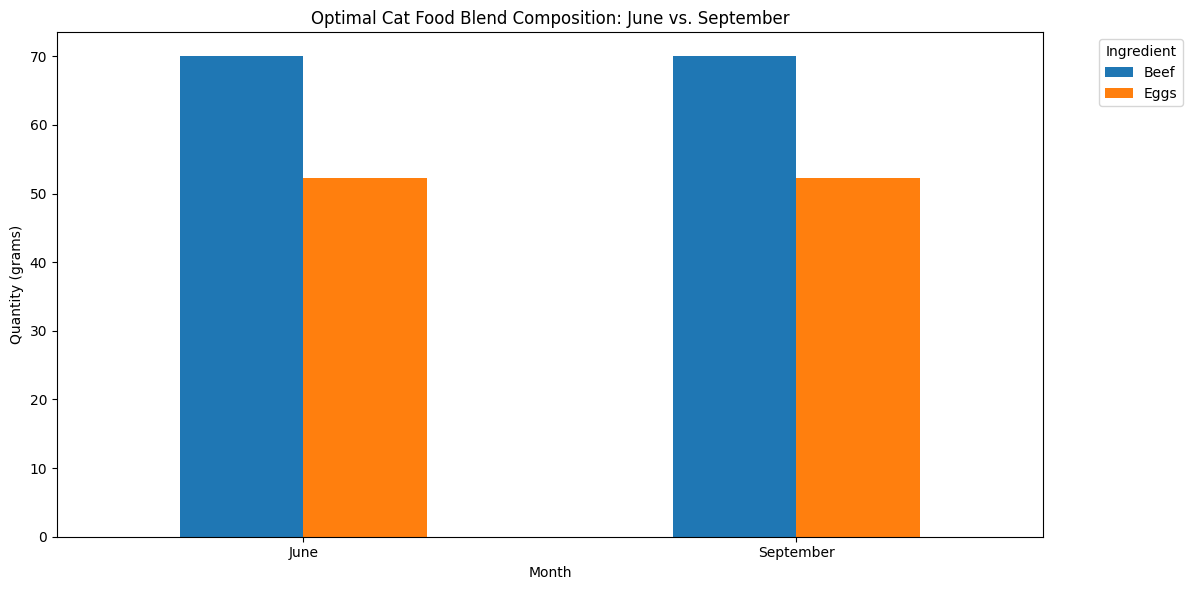


--- Cost Comparison ---
Optimal cost for June: 563.64
Optimal cost for September: 582.37

--- Blend Composition Changes ---
June Blend: {'Beef': 70.0, 'Eggs': 52.307692}
September Blend: {'Beef': 70.0, 'Eggs': 52.307692}


In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a Pandas DataFrame to hold the blend compositions
all_products = sorted(list(set(optimal_blend_june['composition'].keys())
                           .union(set(optimal_blend_september['composition'].keys()))))

june_quantities = [optimal_blend_june['composition'].get(p, 0) for p in all_products]
september_quantities = [optimal_blend_september['composition'].get(p, 0) for p in all_products]

df_comparison = pd.DataFrame({
    'June': june_quantities,
    'September': september_quantities
}, index=all_products)

# Transpose so months become the X-axis
df_plot = df_comparison.T

# 2. Create grouped bar chart
ax = df_plot.plot(kind='bar', figsize=(12, 6))

# 3. Add title, labels, and legend
ax.set_title('Optimal Cat Food Blend Composition: June vs. September')
ax.set_xlabel('Month')
ax.set_ylabel('Quantity (grams)')
plt.xticks(rotation=0)
plt.legend(title='Ingredient', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Costs
print("\n--- Cost Comparison ---")
print(f"Optimal cost for June: {optimal_blend_june['cost']:.2f}")
print(f"Optimal cost for September: {optimal_blend_september['cost']:.2f}")

# 5. Composition summary
print("\n--- Blend Composition Changes ---")
print("June Blend:", optimal_blend_june['composition'])
print("September Blend:", optimal_blend_september['composition'])


# Regression models

Regression models are a type of supervised learning where we estimate a function that maps inputs to outputs.





In [32]:
from google.colab import files
uploaded = files.upload()


Saving sensor_readings_timeseries.csv to sensor_readings_timeseries.csv


In [33]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df_failures = pd.read_csv('sensor_readings_timeseries.csv')

# Display the first few rows to verify loading
print(df_failures.head())

# Display basic information about the DataFrame
print(df_failures.info())

# Display descriptive statistics
df_failures.describe()

   instance_id  machine_id department failure_type   time  sensor_temp  \
0            1           4    Welding   Mechanical    0.0    62.887414   
1            1           4    Welding   Mechanical  100.0    67.749149   
2            1           4    Welding   Mechanical  200.0    63.446070   
3            1           4    Welding   Mechanical  300.0    65.999297   
4            1           4    Welding   Mechanical  400.0    61.228597   

   sensor_vib           rul  near_failure  
0    0.174999  10308.096762             0  
1    0.149790  10208.096762             0  
2    0.202742  10108.096762             0  
3    0.213483  10008.096762             0  
4    0.221188   9908.096762             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190339 entries, 0 to 190338
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   instance_id   190339 non-null  int64  
 1   machine_id    190339 non-null  int64  
 2   

,instance_id,machine_id,time,sensor_temp,sensor_vib,rul,near_failure
count,190339.000000,190339.000000,190339.000000,190339.000000,190339.000000,190339.000000,190339.000000
mean,3953.601327,2.082763,5472.699343,61.548008,1.295366,5426.586009,0.084061
std,2302.519752,1.225247,8678.079374,11.082120,2.353995,8675.590773,0.277479
min,1.000000,1.000000,0.000000,41.868645,0.010000,0.000000,0.000000
25%,1945.000000,1.000000,600.000000,52.771829,0.115480,566.584477,0.000000
50%,3955.000000,1.000000,2000.000000,57.975624,0.158956,1928.113178,0.000000
75%,5947.000000,3.000000,6200.000000,68.487811,1.128911,6125.310478,0.000000
max,8000.000000,4.000000,76285.247981,101.395336,9.781395,76285.247981,1.000000


In [38]:
import subprocess
import os

def try_run(cmd):
    """Runs a shell command and returns True if successful, False if error."""
    try:
        result = subprocess.run(cmd, shell=True, check=False,
                                stdout=subprocess.PIPE,
                                stderr=subprocess.PIPE)
        return result.returncode == 0
    except:
        return False


# --- 1. Attempt running the scripts ---
success1 = try_run("python generate_four_machines.py")
success2 = try_run("python generate_sensor_timeseries.py")

# If any failed -> download files
if not (success1 and success2):
    print("Scripts not found or failed. Downloading from GitHub...")

    if not os.path.exists("data"):
        os.makedirs("data")

    # Download missing scripts
    !curl -L https://raw.githubusercontent.com/AdoHaha/automation_robotics_lab/master/generate_four_machines.py -o generate_four_machines.py
    !curl -L https://raw.githubusercontent.com/AdoHaha/automation_robotics_lab/master/generate_sensor_timeseries.py -o generate_sensor_timeseries.py

    # Try running again
    try_run("python generate_four_machines.py")
    try_run("python generate_sensor_timeseries.py")

print("Done.")


Scripts not found or failed. Downloading from GitHub...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3207  100  3207    0     0  18892      0 --:--:-- --:--:-- --:--:-- 18976
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  6165  100  6165    0     0  29482      0 --:--:-- --:--:-- --:--:-- 29639
Done.


In [66]:
import numpy as np
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_failures[['machine_id', 'time', 'sensor_temp', 'sensor_vib']]
y = df_failures['near_failure']
# Get unique instance IDs
unique_instances = df_failures['instance_id'].unique()

# Split the instance IDs into training and testing sets (70% train, 30% test)
train_instances, test_instances = train_test_split(
    unique_instances,
    test_size=0.3,
    random_state=42
)

# Create train and test sets based on instance IDs
X_train = X[df_failures['instance_id'].isin(train_instances)]
y_train = y[df_failures['instance_id'].isin(train_instances)]

X_test = X[df_failures['instance_id'].isin(test_instances)]
y_test = y[df_failures['instance_id'].isin(test_instances)]

print(f"Training set size: {len(X_train)} samples from {len(train_instances)} instances")
print(f"Testing set size: {len(X_test)} samples from {len(test_instances)} instances")


Training set size: 151993 samples from 6400 instances
Testing set size: 38346 samples from 1600 instances


In [40]:
from sklearn.ensemble import RandomForestClassifier
# Import additional classifiers for comparison
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [67]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier with improved hyperparameters
rf_classifier = RandomForestClassifier(
    n_estimators=300,        # Więcej drzew → mniejsza wariancja, lepsza stabilność
    random_state=42,
    class_weight='balanced', # Obsługa niezbalansowanych danych
    max_depth=10,            # Głębsze drzewa niż 5, ale nadal kontrolują overfitting
    min_samples_split=5,     # Zapobiega zbyt agresywnym podziałom
    min_samples_leaf=2,      # Wygładza granice decyzyjne
    max_features='sqrt'      # Domyślne dla klasyfikacji, poprawia generalizację
)

# Train the classifier
rf_classifier.fit(X_train, y_train)

KeyboardInterrupt: 

In [68]:

from xgboost import XGBClassifier


rf_classifier = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),  # handle class imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
rf_classifier.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:30:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [71]:
from lightgbm import LGBMClassifier
rf_classifier = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42
)
rf_classifier.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 12800, number of negative: 139193
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 770
[LightGBM] [Info] Number of data points in the train set: 151993, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, max_depth=6, n_estimators=500,
               random_state=42, subsample=0.8)

In [72]:
# calculate the accuracy of the model
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.94


In [46]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_classifier = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the classifier on the training data
gradient_boosting_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gradient_boosting_classifier.predict(X_test)



KeyboardInterrupt: 

# Excercise:  Try to get the accuracy to over 98% by changing the model or the parameters

# Excercise:

- A reading for a machine of type 4 was recorded when machine had 110.0 workhours. Its sensor showed a temperature of 87.18 degrees Celsius and a vibration level of 5.96.
- A reading for a machine of type 1 was recorded when machine had 250.0 workhours. Its sensor showed a temperature of 76.05 degrees Celsius and a vibration level of 8.43.
- A reading for a machine of type 3 was recorded when machine had 690.0 workhours. Its sensor showed a temperature of 57.36 degrees Celsius and a vibration level of 0.07.
- A reading for a machine of type 1 was recorded when machine had 20510.0 workhours. Its sensor showed a temperature of 53.30 degrees Celsius and a vibration level of 0.08.
- A reading for a machine of type 2 was recorded when machine had 270.0 workhours. Its sensor showed a temperature of 71.13 degrees Celsius and a vibration level of 0.22.
- A reading for a machine of type 4 was recorded when machine had 110.0 workhours. Its sensor showed a temperature of 67.56 degrees Celsius and a vibration level of 0.13.

You have two technicians available, that cost 600 PLN/hour. You have a budget of 1800 PLN. Each machine requires an hour to service. Which machine to service if machine of the type 1,2 failure cost you 3000 PLN, machine of the 3, 4 failure costs you 2500 PLN?